In [10]:
from datasets import load_dataset
from collections import Counter
import numpy as np
from word2vec import SG_Word2Vec

# Prep the dataset

In [11]:
dataset = load_dataset("wikitext", "wikitext-103-v1")

def flatten(text_list):
    tokens = []
    
    for line in text_list:
        line = line.lower()
        if line.strip() == "":
            continue
        tokens.extend(line.split())
    
    return tokens

tokens = flatten(dataset['train']['text']) + flatten(dataset['validation']['text']) + flatten(dataset['test']['text'])

del dataset

In [12]:
counts = Counter(tokens)
min_count = 5

vocab = {token: i for i, token in enumerate(token for (token, count) in counts.items() if count >= min_count)}

In [13]:
def tokenize(tokens, vocab):
    return np.array([vocab[token] for token in tokens if token in vocab])
    
token_ids = tokenize(tokens, vocab)

vocab_size = np.max(token_ids) + 1

del tokens

In [14]:
def get_relative_freqs(tokens):
    counts = Counter(tokens)
    freq = np.zeros(vocab_size)

    for token, count in counts.items():
        freq[token] = count / len(tokens)
    
    return freq

In [15]:
neg_dist = get_relative_freqs(token_ids) ** 0.75
neg_dist /= neg_dist.sum()

In [ ]:
def subsample(tokens, t = 1e-5):
    freqs = get_relative_freqs(tokens)

    discard_probs = 1 - np.sqrt(t / freqs)

    return np.array([token for token in tokens if np.random.random() > discard_probs[token]])

subsampled_tokens = subsample(token_ids)

del token_ids

# Training

In [25]:
def batch_generator(tokens, batch_size, num_batches, window_size, num_neg_samples):

    for _ in range(num_batches):
        centers = []
        positive_contexts = []

        while len(centers) < batch_size:
            i = np.random.randint(window_size, len(tokens)-window_size)
            center = tokens[i]

            offset = 0
            while offset == 0:
                offset = np.random.randint(-window_size, window_size+1)
                
            positive_context = tokens[i + offset]

            centers.append(center)
            positive_contexts.append(positive_context)

        negative_samples = np.random.choice(
            vocab_size,
            size=(batch_size, num_neg_samples),
            p=neg_dist
        )

        yield (
            np.expand_dims(np.array(centers, dtype=int), axis=-1),
            np.expand_dims(np.array(positive_contexts, dtype=int), axis=-1),
            negative_samples
        )

In [26]:
def train(model, tokens, batch_size, window_size, num_neg_samples, steps, lr):
    total_loss = 0
    for centers, positive_contexts, negative_samples in batch_generator(tokens, batch_size, steps, window_size, num_neg_samples):
        total_loss += model.training_step(centers, positive_contexts, negative_samples, lr)
    
    return total_loss / steps

In [28]:
model = SG_Word2Vec(vocab_size, 300)

batch_size = 256
window_size = 5
num_neg_samples = 20

max_epochs = 500

patience = 8

epochs_without_improvement = 0
best_loss = float('inf')

steps_per_epoch = 250
validate_evaluate_steps = 50
test_evaluate_steps = 500

lr = 0.05

for epoch in range(max_epochs):
    loss = train(model, subsampled_tokens, batch_size, window_size, num_neg_samples, steps_per_epoch, lr)

    if loss < best_loss:
        best_loss = loss
        epochs_without_improvement = 0
    else:
        epochs_without_improvement += 1
    
    if epochs_without_improvement > patience:
        print("Early stopping")
        break

    print(f"epoch {epoch+1} | loss {loss:.4f}")

epoch 1 | loss 13.8410
epoch 2 | loss 10.5176
epoch 3 | loss 8.5090
epoch 4 | loss 7.5318
epoch 5 | loss 6.9402
epoch 6 | loss 6.5226
epoch 7 | loss 6.2249
epoch 8 | loss 5.9991
epoch 9 | loss 5.8061
epoch 10 | loss 5.6337
epoch 11 | loss 5.4865
epoch 12 | loss 5.3825
epoch 13 | loss 5.3121
epoch 14 | loss 5.1927
epoch 15 | loss 5.1241
epoch 16 | loss 5.0492
epoch 17 | loss 4.9827
epoch 18 | loss 4.9399
epoch 19 | loss 4.8842
epoch 20 | loss 4.8416
epoch 21 | loss 4.8084
epoch 22 | loss 4.7561
epoch 23 | loss 4.7260
epoch 24 | loss 4.6844
epoch 25 | loss 4.6507
epoch 26 | loss 4.6401
epoch 27 | loss 4.5987
epoch 28 | loss 4.5710
epoch 29 | loss 4.5489
epoch 30 | loss 4.5326
epoch 31 | loss 4.5054
epoch 32 | loss 4.4879
epoch 33 | loss 4.4588
epoch 34 | loss 4.4476
epoch 35 | loss 4.4397
epoch 36 | loss 4.4184
epoch 37 | loss 4.4130
epoch 38 | loss 4.3878
epoch 39 | loss 4.3717
epoch 40 | loss 4.3589
epoch 41 | loss 4.3501
epoch 42 | loss 4.3377
epoch 43 | loss 4.3267
epoch 44 | loss 4.

KeyboardInterrupt: 

# PCA Visualisation

In [29]:
def pca(X, n_components):
    X_mean = np.mean(X, axis=0)
    X_centered = X - X_mean

    U, S, Vt = np.linalg.svd(X_centered, full_matrices=False)

    principal_components = Vt[:n_components, :].T

    X_reduced = X_centered @ principal_components

    return X_reduced

In [30]:
norms = np.linalg.norm(model.input_embeddings, axis=1, keepdims=True)
embeddings_normalised = model.input_embeddings / norms

projected_embeddings = pca(embeddings_normalised, 2)

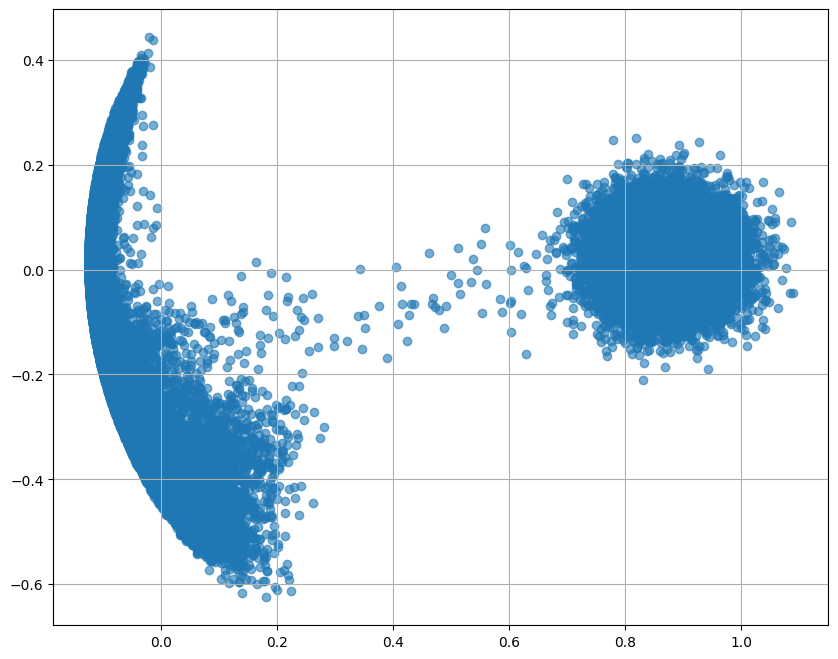

In [31]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))
plt.scatter(projected_embeddings[:, 0], projected_embeddings[:, 1], alpha=0.6)

plt.grid(True)
plt.show()

# T-sne (using sklearn, just for testing sake)

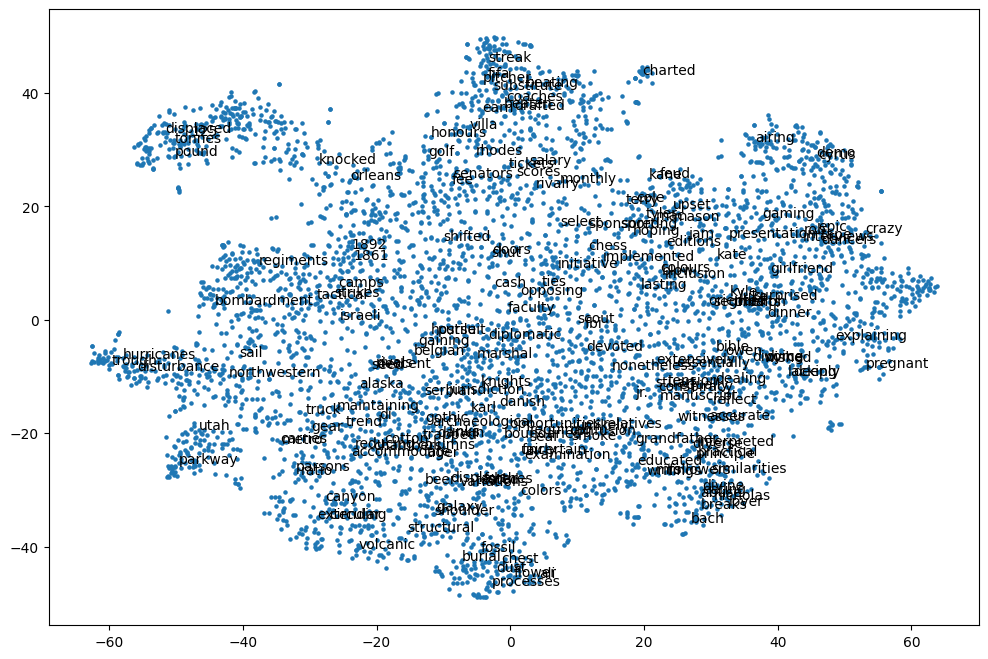

In [ ]:
from sklearn.manifold import TSNE

freqs = get_relative_freqs(subsampled_tokens)
top_tokens = np.argsort(freqs)[-5000:][::-1]

id_to_word = {i:token for token, i in vocab.items()}

top_embeddings = model.input_embeddings[top_tokens]

tsne = TSNE(n_components=2, perplexity=30)
emb_2d = tsne.fit_transform(top_embeddings)

plt.figure(figsize=(12,8))
plt.scatter(emb_2d[:,0], emb_2d[:,1], s=5)

for i, token_id in enumerate(top_tokens[:]):
    plt.text(emb_2d[,0], emb_2d[i,1], id_to_word[token_id], fontsize=10)

plt.show()